In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

### Helper Functions

In [3]:
def cohens_d(first_group, second_group):
    t = stats.ttest_ind(first_group, second_group, equal_var=True).statistic

    return t * np.sqrt(1 / len(first_group) + 1 / len(second_group))

In [2]:
def compare_stats(data, group1, group2):
    df1 = data[data["dataset"] == group1]
    df2 = data[data["dataset"] == group2]

    columns = pd.MultiIndex.from_tuples([
        ("x", group1.capitalize()), ("x", group2.capitalize()),
        ("y", group1.capitalize()), ("y", group2.capitalize())
    ])

    comparison = pd.DataFrame([
        [df1["x"].mean(), df2["x"].mean(), df1["y"].mean(), df2["y"].mean()],
        [df1["x"].median(), df2["x"].median(), df1["y"].median(), df2["y"].median()],
        [df1["x"].var(), df2["x"].var(), df1["y"].var(), df2["y"].var()],
        [df1["x"].std(), df2["x"].std(), df1["y"].std(), df2["y"].std()],
        [abs(cohens_d(df1["x"], df2["x"])), abs(cohens_d(df1["x"], df2["x"])),
         abs(cohens_d(df1["y"], df2["y"])), abs(cohens_d(df1["y"], df2["y"]))]
    ], index=["Mean", "Median", "Variance", "Std Dev", "Cohen's d"], columns=columns)

    display(comparison.round(3))

In [4]:
def plot_pair(data, datasets):
    sns.set_theme(style="darkgrid", context="notebook")
    subset = data[data["dataset"].isin(datasets)]
    grid = sns.FacetGrid(
        subset,
        col="dataset",
        col_wrap=2,
        height=4,
        sharex=True,
        sharey=True,
    )
    grid.map_dataframe(
        sns.scatterplot,
        x="x",
        y="y",
        s=20,
        linewidth=0,
    )
    grid.set(xlim=(0, 100), ylim=(0, 100))
    grid.set_axis_labels("x", "y")
    grid.set_titles("{col_name}")
    plt.show()

### Datasaurus

In [5]:
datasaurus_url = (
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/"
    "main/data/2020/2020-10-13/datasaurus.csv"
)

datasaurus_df = pd.read_csv(datasaurus_url)

In [6]:
datasaurus_df.shape

(1846, 3)

In [7]:
datasaurus_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1846 entries, 0 to 1845
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dataset  1846 non-null   str    
 1   x        1846 non-null   float64
 2   y        1846 non-null   float64
dtypes: float64(2), str(1)
memory usage: 55.7 KB


In [8]:
datasaurus_df.head()

,dataset,x,y
0,dino,55.3846,97.1795
1,dino,51.5385,96.0256
2,dino,46.1538,94.4872
3,dino,42.8205,91.4103
4,dino,40.7692,88.3333


In [9]:
datasaurus_df["dataset"].value_counts()

dataset
dino          142
away          142
h_lines       142
v_lines       142
x_shape       142
star          142
high_lines    142
dots          142
circle        142
bullseye      142
slant_up      142
slant_down    142
wide_lines    142
Name: count, dtype: int64

In [10]:
star = datasaurus_df.loc[
    datasaurus_df["dataset"] == "star",
    ["x", "y"],
]

dino = datasaurus_df.loc[
    datasaurus_df["dataset"] == "dino",
    ["x", "y"],
]

## Mean (Média Aritmética)

$$ \bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i $$

Onde:
*   $\bar{x}$ representa a sample mean (média amostral).
*   $n$ é o número de observations (observações) no dataset (conjunto de dados).
*   $x_i$ representa cada value (valor) individual.
*   $\sum$ (Sigma) indica a sum (soma) dos values (valores).

In [11]:
print(f"Dino's mean: {dino["x"].mean():.3f}, {dino["y"].mean():.3f}")
print(f"Star's mean: {star["x"].mean():.3f}, {star["y"].mean():.3f}")

Dino's mean: 54.263, 47.832
Star's mean: 54.267, 47.840


## Median (Mediana)

Para um conjunto de dados ordenado $x_1, x_2, \dots, x_n$:

Se $n$ é ímpar:
$$ \text{Mediana} = x_{\frac{n+1}{2}} $$

Se $n$ é par:
$$ \text{Mediana} = \frac{x_{\frac{n}{2}} + x_{\frac{n}{2} + 1}}{2} $$

Onde:
*   $n$ é o número de observations (observações) no dataset (conjunto de dados).
*   $x$ representa os values (valores) individuais ordenados em ordem crescente.

In [12]:
print(f"Dino's mediana: {dino["x"].median():.3f}, {dino["y"].median():.3f}")
print(f"Star's mean: {star["x"].median():.3f}, {star["y"].median():.3f}")

Dino's mediana: 53.333, 46.026
Star's mean: 56.535, 50.111


## Variance (Variância)

$$ s^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2 $$

Onde:
*   $s^2$ representa a sample variance (variância amostral).
*   $n$ é o número de observations (observações) no dataset (conjunto de dados).
*   $x_i$ representa cada value (valor) individual.
*   $\bar{x}$ representa a sample mean (média amostral).
*   $\sum$ indica a sum (soma) das squared differences (diferenças ao quadrado).

In [13]:
print(f"Dino's variance: {dino["x"].var():.3f}, {dino["y"].var():.3f}")
print(f"Star's variance: {star["x"].var():.3f}, {star["y"].var():.3f}")

Dino's variance: 281.070, 725.516
Star's variance: 281.198, 725.240


## Standard Deviation (Desvio Padrão)

$$ s = \sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2} $$

Onde:
*   $s$ representa a sample standard deviation (desvio padrão amostral).
*   $n$ é o número de observations (observações) no dataset (conjunto de dados).
*   $x_i$ representa cada value (valor) individual.
*   $\bar{x}$ representa a sample mean (média amostral).
*   $\sum$ indica a sum (soma) das squared differences (diferenças ao quadrado).

In [14]:
print(f"Dino's desvio padrão: {dino["x"].std():.3f}, {dino["y"].std():.3f}")
print(f"Star's desvio padrão: {star["x"].std():.3f}, {star["y"].std():.3f}")

Dino's desvio padrão: 16.765, 26.935
Star's desvio padrão: 16.769, 26.930


## Cohens D

$$ d = \frac{\bar{x}_1 - \bar{x}_2}{s_p} $$

Onde o pooled standard deviation (desvio padrão agrupado) ($s_p$) é calculado como:

$$ s_p = \sqrt{\frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1+n_2-2}} $$

Onde:
*   $d$ representa o Cohen's *d* (d de Cohen).
*   $\bar{x}_1$ e $\bar{x}_2$ são as sample means (médias amostrais) do grupo 1 e grupo 2, respectivamente.
*   $s_p$ é o pooled standard deviation (desvio padrão agrupado).
*   $s_1^2$ e $s_2^2$ são as sample variances (variâncias amostrais) do grupo 1 e grupo 2.
*   $n_1$ e $n_2$ são os sample sizes (tamanhos das amostras) do grupo 1 e grupo 2.

In [15]:
print(f"Cohens D ('x'): {abs(cohens_d(dino["x"], star["x"])):.4f}")
print(f"Cohens D ('y'): {abs(cohens_d(dino["y"], star["y"])):.4f}")

Cohens D ('x'): 0.0002
Cohens D ('y'): 0.0003


In [16]:
dino_star_comparison = compare_stats(datasaurus_df, "dino", "star")

x                 y         
              Dino     Star     Dino     Star
Mean        54.263   54.267   47.832   47.840
Median      53.333   56.535   46.026   50.111
Variance   281.070  281.198  725.516  725.240
Std Dev     16.765   16.769   26.935   26.930
Cohen's d    0.000    0.000    0.000    0.000

In [17]:
dino_star_comparison = compare_stats(datasaurus_df, "bullseye", "away")

x                 y         
          Bullseye     Away Bullseye     Away
Mean        54.269   54.266   47.831   47.835
Median      53.842   53.340   47.383   47.535
Variance   281.207  281.227  725.533  725.750
Std Dev     16.769   16.770   26.936   26.940
Cohen's d    0.000    0.000    0.000    0.000

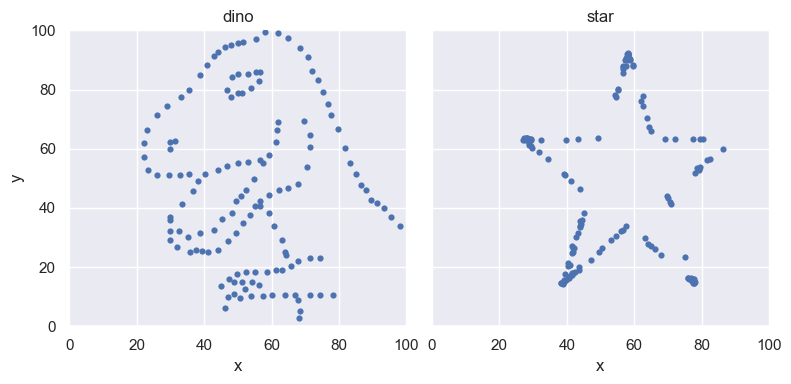

In [18]:
plot_pair(data=datasaurus_df, datasets=["dino", "star"])

In [19]:
bullseye = datasaurus_df.loc[
    datasaurus_df["dataset"] == "bullseye",
    ["x", "y"],
]

away = datasaurus_df.loc[
    datasaurus_df["dataset"] == "away",
    ["x", "y"],
]

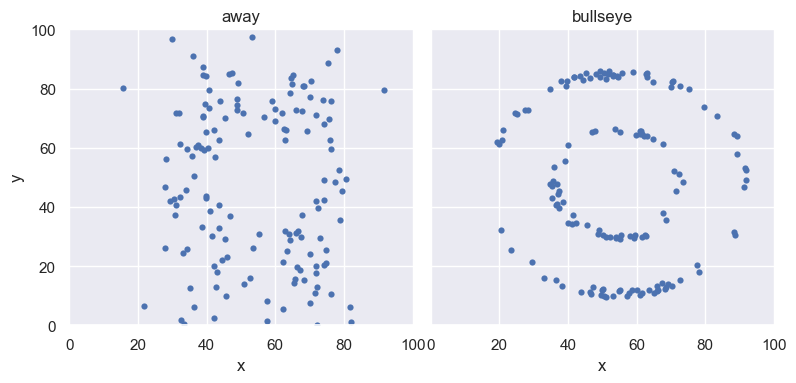

In [20]:
plot_pair(data=datasaurus_df, datasets=["bullseye", "away"])

In [21]:
from scipy.spatial import ConvexHull, KDTree
from statsmodels.stats.dist_dependence_measures import distance_correlation

def get_points(dataset_df):
    return dataset_df[["x", "y"]].dropna().to_numpy()

def median_abs_dev_norm(points):
    mav = stats.median_abs_deviation(
        points,
        scale="normal",
    )
    return np.linalg.norm(mav)


def cliffs_delta(first_group, second_group):
    first_group = np.asarray(first_group)
    second_group = np.asarray(second_group)

    first_group = first_group[~np.isnan(first_group)]
    second_group = second_group[~np.isnan(second_group)]

    greater_count = 0
    lesser_count = 0

    for first_value in first_group:
        greater_count += np.sum(first_value > second_group)
        lesser_count += np.sum(first_value < second_group)

    return (greater_count - lesser_count) / (
        len(first_group) * len(second_group)
    )

def vargha_delaney_a(first_group, second_group):

    return (cliffs_delta(first_group, second_group) + 1) / 2


def spatial_entropy(points, bins=12):
    counts, _, _ = np.histogram2d(
        points[:, 0],
        points[:, 1],
        bins=bins,
    )

    probabilities = counts.ravel()
    probabilities = probabilities[probabilities > 0]
    probabilities = probabilities / probabilities.sum()

    return stats.entropy(probabilities, base=2)


def occupied_bin_rate(points, bins=12):
    counts, _, _ = np.histogram2d(
        points[:, 0],
        points[:, 1],
        bins=bins,
    )

    return np.count_nonzero(counts) / counts.size


def pca_eigenvalues(points):
    covariance_matrix = np.cov(points, rowvar=False)
    return np.linalg.eigvalsh(covariance_matrix)


def mean_nearest_neighbour_distance(points):
    tree = KDTree(points)
    distances, _ = tree.query(points, k=2)

    return distances[:, 1].mean()


def polynomial_r_squared(points, degree=3):
    x_values = points[:, 0]
    y_values = points[:, 1]

    coefficients = np.polyfit(x_values, y_values, deg=degree)
    predicted_y = np.polyval(coefficients, x_values)

    residual_sum_squares = np.sum((y_values - predicted_y) ** 2)
    total_sum_squares = np.sum((y_values - y_values.mean()) ** 2)

    return 1 - residual_sum_squares / total_sum_squares


def shape_metrics(dataset_df, ref_df=None, bins=12):
    points = get_points(dataset_df)

    x_values = points[:, 0]
    y_values = points[:, 1]

    hull = ConvexHull(points)
    hull_center_x = points[hull.vertices, 0].mean()
    hull_center_y = points[hull.vertices, 1].mean()

    metrics = {
        "mean_norm": np.linalg.norm([x_values.mean(), y_values.mean()]),
        "median_norm": np.linalg.norm([np.median(x_values), np.median(y_values)]),
        "hull_center_norm": np.linalg.norm([hull_center_x, hull_center_y]),
        "std_norm": np.linalg.norm([x_values.std(ddof=1), y_values.std(ddof=1)]),
        "iqr_norm": np.linalg.norm([stats.iqr(x_values), stats.iqr(y_values)]),
        "mad_norm": median_abs_dev_norm(points),
        "pearson": stats.pearsonr(x_values, y_values).statistic,
        "spearman": stats.spearmanr(x_values, y_values).statistic,
        "kendall": stats.kendalltau(x_values, y_values).statistic,
        "distance_corr": distance_correlation(x_values, y_values),
        "poly3_r2": polynomial_r_squared(points, degree=3),
        "hull_area": hull.volume,
        "hull_perimeter": hull.area,
        "spatial_entropy": spatial_entropy(points, bins=bins),
        "mean_nn_distance": mean_nearest_neighbour_distance(points),
    }

    if ref_df is not None:
        ref_points = get_points(ref_df)
        ref_x = ref_points[:, 0]
        ref_y = ref_points[:, 1]

        cd_x = cohens_d(x_values, ref_x)
        cd_y = cohens_d(y_values, ref_y)
        metrics["cohens_d_norm"] = np.linalg.norm([cd_x, cd_y])

        vd_x = vargha_delaney_a(x_values, ref_x)
        vd_y = vargha_delaney_a(y_values, ref_y)
        metrics["vargha_delaney_a_norm"] = 0.5 + np.linalg.norm([vd_x - 0.5, vd_y - 0.5])

        del_x = cliffs_delta(x_values, ref_x)
        del_y = cliffs_delta(y_values, ref_y)
        metrics["cliffs_delta_norm"] = np.linalg.norm([del_x, del_y])

    return metrics

In [25]:
rows = []

ref_dino = datasaurus_df[datasaurus_df["dataset"] == "dino"]

for dataset_name, dataset_df in datasaurus_df.groupby("dataset"):
    rows.append(
        {
            "dataset": dataset_name,
            **shape_metrics(dataset_df, ref_df=ref_dino, bins=12),
        }
    )

shape_summary = (
    pd.DataFrame(rows)
    .set_index("dataset")
    .sort_index()
)

metric_categories = {
    "mean_norm": "Center",
    "median_norm": "Center",
    "hull_center_norm": "Center",
    "std_norm": "Dispersion",
    "mad_norm": "Dispersion",
    "iqr_norm": "Dispersion",
    "spatial_entropy": "Dispersion",
    "cohens_d_norm": "Effect Size",
    "cliffs_delta_norm": "Effect Size",
    "vargha_delaney_a_norm": "Effect Size",
    "pearson": "Correlation",
    "spearman": "Correlation",
    "kendall": "Correlation",
    "distance_corr": "Correlation",
    "poly3_r2": "Correlation",
    "hull_area": "Geometry",
    "hull_perimeter": "Geometry",
    "mean_nn_distance": "Geometry"
}

shape_summary.columns = pd.MultiIndex.from_tuples(
    [(metric_categories.get(col, "Other"), col) for col in shape_summary.columns],
    names=["Category", "Metric"]
)

In [ ]:
display(shape_summary["Center"].round(3))

Metric,mean_norm,median_norm,hull_center_norm
dataset,,,
away,72.339,71.448,73.326
bullseye,72.339,71.722,72.035
circle,72.342,74.311,67.128
dino,72.336,70.447,81.043
dots,72.338,72.320,72.721
h_lines,72.333,73.239,72.262
high_lines,72.342,63.170,76.140
slant_down,72.341,70.544,74.013
slant_up,72.337,70.680,77.366


In [26]:
# Dispersion Metrics
display(shape_summary["Dispersion"].round(3))

Metric,std_norm,iqr_norm,mad_norm,spatial_entropy
dataset,,,,
away,31.733,55.600,41.696,6.048
bullseye,31.729,51.764,40.775,5.284
circle,31.719,63.234,44.786,4.864
dino,31.727,47.911,34.686,5.924
dots,31.724,70.308,47.069,3.161
h_lines,31.731,46.782,34.614,5.488
high_lines,31.731,57.563,27.829,5.520
slant_down,31.728,45.977,32.929,5.478
slant_up,31.731,50.942,37.448,5.400


In [27]:
display(shape_summary["Effect Size"].round(3))

Metric,cohens_d_norm,vargha_delaney_a_norm,cliffs_delta_norm
dataset,,,
away,0.0,0.508,0.015
bullseye,0.0,0.503,0.007
circle,0.0,0.507,0.015
dino,0.0,0.500,0.000
dots,0.0,0.508,0.016
h_lines,0.0,0.507,0.013
high_lines,0.0,0.508,0.016
slant_down,0.0,0.502,0.004
slant_up,0.0,0.501,0.003


In [28]:
# Correlation Metrics
display(shape_summary["Correlation"].round(3))

Metric,pearson,spearman,kendall,distance_corr,poly3_r2
dataset,,,,,
away,-0.064,-0.057,-0.035,0.133,0.007
bullseye,-0.069,-0.079,-0.052,0.176,0.015
circle,-0.068,-0.077,-0.017,0.229,0.012
dino,-0.064,-0.065,-0.048,0.164,0.008
dots,-0.060,-0.126,-0.082,0.127,0.005
h_lines,-0.062,-0.052,-0.043,0.155,0.010
high_lines,-0.069,-0.003,-0.009,0.148,0.045
slant_down,-0.069,-0.067,-0.075,0.162,0.007
slant_up,-0.069,-0.086,-0.028,0.193,0.011


In [29]:
# Geometry Metrics
display(shape_summary["Geometry"].round(3))

Metric,hull_area,hull_perimeter,mean_nn_distance
dataset,,,
away,6356.653,304.122,3.262
bullseye,4420.919,237.664,1.603
circle,3199.043,203.192,0.724
dino,4801.251,260.926,2.896
dots,3769.475,241.734,0.215
h_lines,4952.149,262.691,1.217
high_lines,4340.922,247.493,2.123
slant_down,5277.299,269.156,1.775
slant_up,4808.993,258.066,1.783
